<a href="https://colab.research.google.com/github/cpatel6/skills-code-with-codespaces/blob/main/a3_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: Language models

In this assignment we will work on language model, especially its decoding generation procedure.  
1. Explore the language model (5')  
2. Greedy decoding (5')  
3. Beam search decoding (5')  
4. Visualization (5')  
5. Generation hyperparameters (10')  

In [9]:
!pip install anytree

In [10]:
# Import the packages
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np

# Packages for visualization
from anytree import Node, RenderTree
from anytree.exporter import DotExporter
import matplotlib.pyplot as plt
from IPython.display import Image, display

### 0. Load a pre-trained model
Load a pre-trained language model, `meta-llama/Llama-3.2-1B`, using `AutoModelForCausalLM` class. This requires creating an account at huggingface and creating an access token. You'll also need to submit a request at [huggingface](https://huggingface.co/meta-llama/Llama-3.2-1B) to use it.
An $X$ B model contains $X$ billion parameters. To run inference on this model, you'll need $4X$ GB memory on full precision. You can reduce it to $2X$ GB by specifying `torch_dtype=torch.float16` in the `from_pretrained()` step. If your computer does not have 2GB spare memory, you can use Google Colab or a smaller model like `gpt2-large`. To speed up the inference, you can load the model onto cuda (for the machines with NVidia GPU) or mps (for the machines with Apple Silicon).  

In [29]:
# Load the pre-trained model and tokenizer
# model_name = "meta-llama/Llama-3.2-1B"
model_name = "gpt2-large"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

tokenizer.pad_token = tokenizer.eos_token

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 1. Explore the language model (5')
Tokenize the sentence "An apple a day keeps the doctor away." with the tokenizer of this LM. Print out the outputs and briefly comment on it.  

Pass the tokenized result to the LM. Comment on the model's outputs (specifically, the `logits` and the `past_key_values`). Instead of printing out the logits, print out the shapes of the logits and comment on them.  

In [35]:
# TODO: tokenize the sentence and pass to LM
sentence = "An apple a day keeps the doctor away."
tokens = tokenizer.encode(sentence, return_tensors="pt").to(device)
print(tokens)
print(f"Tokens: {tokenizer.convert_ids_to_tokens(tokens[0])}")
print(f"Number of tokens: {tokens.shape[1]}")
outputs = model(inputs, output_hidden_states=True, use_cache=True)

tensor([[ 2025, 17180,   257,  1110,  7622,   262,  6253,  1497,    13]],
       device='cuda:0')
Tokens: ['An', 'Ġapple', 'Ġa', 'Ġday', 'Ġkeeps', 'Ġthe', 'Ġdoctor', 'Ġaway', '.']
Number of tokens: 9


In [36]:
# TODO: model's o utputs
print("\nModel outputs keys:", outputs.keys())


Model outputs keys: odict_keys(['logits', 'past_key_values', 'hidden_states'])


In [39]:
# TODO: shapes of the logits
logits = outputs.logits
print(f"\nLogits shape: {logits.shape}")

print(f"Past key values: {len(outputs.past_key_values)}")


Logits shape: torch.Size([1, 9, 50257])
Past key values: 36


### 2. Greedy decoding (5')
Implement greedy decoding. With greedy decoding, decode a batch of sentences (from the first word). Following are the sentences:  

> An apple a day keeps the doctors away.  
> Tell me a story.  
> Shut up!    
> Hey what's up?  
> Better late than never.  

Decode until either the model predicts an "end-of-sentence" token, or until the sequence reaches a maximum length (L=5).  

For each step, print out appropriate results to show the correctness of greedy decoding (e.g., the word with the highest probability).  

Do not call the `model.generate()` method in this question -- assignments using this method won't get scores for this part.

Do the sentences decoded based on the first word match the original sentences? Comment on the results.  

In [48]:
def get_topk(logits, k):
    probs = torch.softmax(logits, dim=-1)
    top_k_probs, top_k_ids = torch.topk(probs, k)
    return top_k_probs, top_k_ids

def greedy_decode_one_sentence(prompt, max_length=5):
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    decoded_sentence = prompt  # TODO: modify this line

    for step in range(max_length):
        # TODO: continue
        outputs = model(input_ids)

        # Get logits for the last token
        next_token_logits = outputs.logits[0, -1, :]

        # Get the token with highest probability (greedy)
        next_token_id = torch.argmax(next_token_logits, dim=-1, keepdim=True)

        # Get the probability
        probs = torch.softmax(next_token_logits, dim=-1)
        next_token_prob = probs[next_token_id.item()].item()
        next_token_word = tokenizer.decode([next_token_id.item()])

        print(f"Step {step+1}: {next_token_word} (prob: {next_token_prob:.4f})")

        # Check for end-of-sequence
        if next_token_id.item() == tokenizer.eos_token_id:
            break

        # Append to sequence
        input_ids = torch.cat([input_ids, next_token_id.unsqueeze(0)], dim=1)
        decoded_sentence += next_token_word

    return decoded_sentence

greedy_decode_one_sentence("Once", max_length=5)
# sentences = ["An apple a day keeps the doctors away.", "Tell me a story.", "Shut up!",
#              "Hey what's up?", "Better late than never."]
# start_words = [s.split()[0] for s in sentences]

# for word in start_words:
#     print(f"\n{'='*50}")
#     print(f"Decoding from: {word}")
#     print(f"{'='*50}")
#     result = greedy_decode_one_sentence(word, max_length=5)
#     print(f"Result: {result}\n")

Step 1:  you (prob: 0.2022)
Step 2:  have (prob: 0.2643)
Step 3:  the (prob: 0.1184)
Step 4:  files (prob: 0.0197)
Step 5: , (prob: 0.2530)


'Once you have the files,'

In [43]:
def greedy_decoding(model, tokenizer, start_of_sentences):
    for prompt in start_of_sentences:
        greedy_decode_one_sentence(prompt)

sentences = ["An apple a day keeps the doctors away.", "Tell me a story.", "Shut up!",
"Hey what's up?", "Better late than never."]

greedy_decoding(model, tokenizer, [s.split()[0] for s in sentences])

Step 1:  example (prob: 0.0188)
Step 2:  of (prob: 0.5123)
Step 3:  a (prob: 0.2378)
Step 4:  " (prob: 0.0166)
Step 5: good (prob: 0.0084)
Step 1:  me (prob: 0.2474)
Step 2:  about (prob: 0.1923)
Step 3:  the (prob: 0.2579)
Step 4:  first (prob: 0.0165)
Step 5:  time (prob: 0.4617)
Step 1: down (prob: 0.1518)
Step 2: . (prob: 0.0519)
Step 3: exe (prob: 0.1883)
Step 4:  / (prob: 0.2616)
Step 5: n (prob: 0.1055)
Step 1: , (prob: 0.5017)
Step 2:  I (prob: 0.0926)
Step 3: 'm (prob: 0.2581)
Step 4:  not (prob: 0.1039)
Step 5:  going (prob: 0.1051)
Step 1:  than (prob: 0.1227)
Step 2:  the (prob: 0.1051)
Step 3:  original (prob: 0.0421)
Step 4: , (prob: 0.0879)
Step 5:  but (prob: 0.2099)


### 3. Beam search decoding (5')
Implement beam search decoding. With beam search, decode the same batch of sentences (also decoding from the first word).

Do not call the `model.generate()` method -- assignments using this method won't get scores for this part. Try different beam sizes, and comment on their impacts.  

At each step, print out the appropriate intermediate results that illustrate the correctness of beam search (e.g., the top k words and the logprobs of these beams).  

In [44]:
def keep_best_k(all_probs, all_tokens, all_parents, k):
    L = [(p, t, a) for p,t,a in zip(all_probs, all_tokens, all_parents)]
    Ls = sorted(L, key=lambda item: -item[0])[:k]
    return [item[0] for item in Ls], [item[1] for item in Ls], [item[2] for item in Ls]

def beam_decode_one_sentence(prompt, max_length=5, k=3):
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    # beams = [input_ids]  # k beams, each of them an input_ids (tensor with sizes 1xlen)
    # beam_probs = [0.0 for b in range(k)]  # k beams, each of them a prob of the beam

    beams = [(input_ids, 0.0)]

    for step in range(max_length):
        # TODO: implement
        all_candidates = []

        for beam_idx, (beam_ids, beam_prob) in enumerate(beams):
            with torch.no_grad():
                outputs = model(beam_ids)

            next_token_logits = outputs.logits[0, -1, :]
            log_probs = torch.log_softmax(next_token_logits, dim=-1)

            # Get top k next tokens
            top_k_log_probs, top_k_ids = torch.topk(log_probs, k)

            for idx in range(k):
                next_id = top_k_ids[idx].item()
                next_log_prob = top_k_log_probs[idx].item()
                total_log_prob = beam_prob + next_log_prob

                new_ids = torch.cat([beam_ids, torch.tensor([[next_id]], device=device)], dim=1)
                all_candidates.append((new_ids, total_log_prob, beam_idx))

        # Keep top k beams
        all_candidates.sort(key=lambda x: x[1], reverse=True)
        beams = [(ids, prob) for ids, prob, _ in all_candidates[:k]]

        print(f"Step {step+1}:")
        for i, (beam_ids, prob) in enumerate(beams):
            decoded = tokenizer.decode(beam_ids[0].tolist())
            print(f"  Beam {i+1}: {decoded} (log_prob: {prob:.4f})")

    best_ids, best_prob = beams[0]
    decoded_sentence = tokenizer.decode(best_ids[0].tolist())  # TODO: implement
    return decoded_sentence

# beam_decode_one_sentence("Once", max_length=5)
print("\nBeam Search (k=3):")
for word in start_words[:2]:
    print(f"\n{'='*50}")
    print(f"Beam searching from: {word}")
    print(f"{'='*50}")
    result = beam_decode_one_sentence(word, max_length=5, k=3)
    print(f"\nFinal result: {result}\n")


Beam Search (k=3):

Beam searching from: An
Step 1:
  Beam 1: An example (log_prob: -3.9719)
  Beam 2: Annie (log_prob: -4.7054)
  Beam 3: An important (log_prob: -4.7095)
Step 2:
  Beam 1: An example of (log_prob: -4.6407)
  Beam 2: An example: (log_prob: -6.5278)
  Beam 3: An example is (log_prob: -6.9127)
Step 3:
  Beam 1: An example of a (log_prob: -6.0769)
  Beam 2: An example of the (log_prob: -6.4551)
  Beam 3: An example of this (log_prob: -6.6518)
Step 4:
  Beam 1: An example of this is (log_prob: -7.5849)
  Beam 2: An example of this would (log_prob: -9.3428)
  Beam 3: An example of this was (log_prob: -9.6638)
Step 5:
  Beam 1: An example of this is the (log_prob: -8.6803)
  Beam 2: An example of this would be (log_prob: -9.3583)
  Beam 3: An example of this is a (log_prob: -10.3139)

Final result: An example of this is the


Beam searching from: Tell
Step 1:
  Beam 1: Tell me (log_prob: -1.3966)
  Beam 2: Tell us (log_prob: -1.6849)
  Beam 3: Tell you (log_prob: -1.7874)
S

### 4. Visualization (5')
Modify the previously implemented `greedy search` and `beam search` algorithms. Introduce visualizations that show the top-3 probabilities each step. Run both algorithms through one sentence each.  
You can choose the appropriate visualization package and decide the tree structures. For this question, please feel free to use LLM to search for and choose an appropriate visualization tools.  

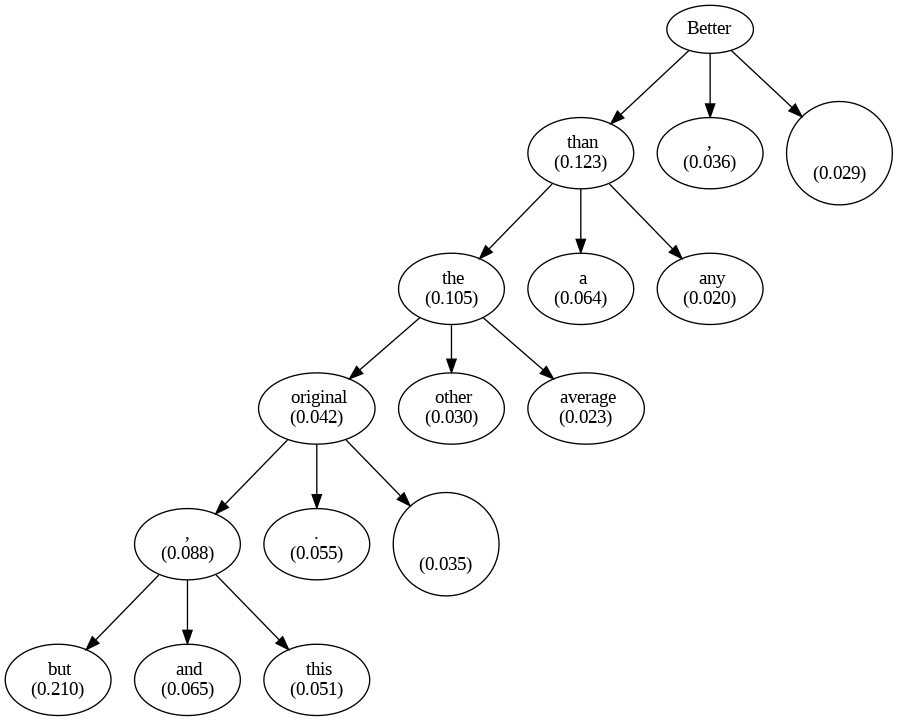

In [56]:
def greedy_decode_one_sentence_with_visualization(prompt, max_length=10, export_figure_filename="decode_tree_greedy.png"):
    # TODO
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    root = Node(prompt, prob=1.0)
    current_node = root

    for step in range(max_length):
        with torch.no_grad():
            outputs = model(input_ids)

        next_token_logits = outputs.logits[0, -1, :]
        probs = torch.softmax(next_token_logits, dim=-1)
        top_k_probs, top_k_ids = torch.topk(probs, 3)

        # Create nodes for top-3 tokens
        for prob, token_id in zip(top_k_probs, top_k_ids):
            word = tokenizer.decode([token_id.item()])
            child = Node(f"{word}\n({prob:.3f})", parent=current_node, prob=prob.item())

        # Continue with greedy choice
        next_token_id = top_k_ids[0]
        if next_token_id.item() == tokenizer.eos_token_id:
            break

        input_ids = torch.cat([input_ids,  next_token_id.view(1, 1)], dim=1)
        current_node = current_node.children[0]

    # Export to image
    DotExporter(root).to_picture(export_figure_filename)
    return root

# greedy_decode_one_sentence_with_visualization("Better")
greedy_decode_one_sentence_with_visualization("Better", max_length=5)
display(Image(filename="decode_tree_greedy.png"))

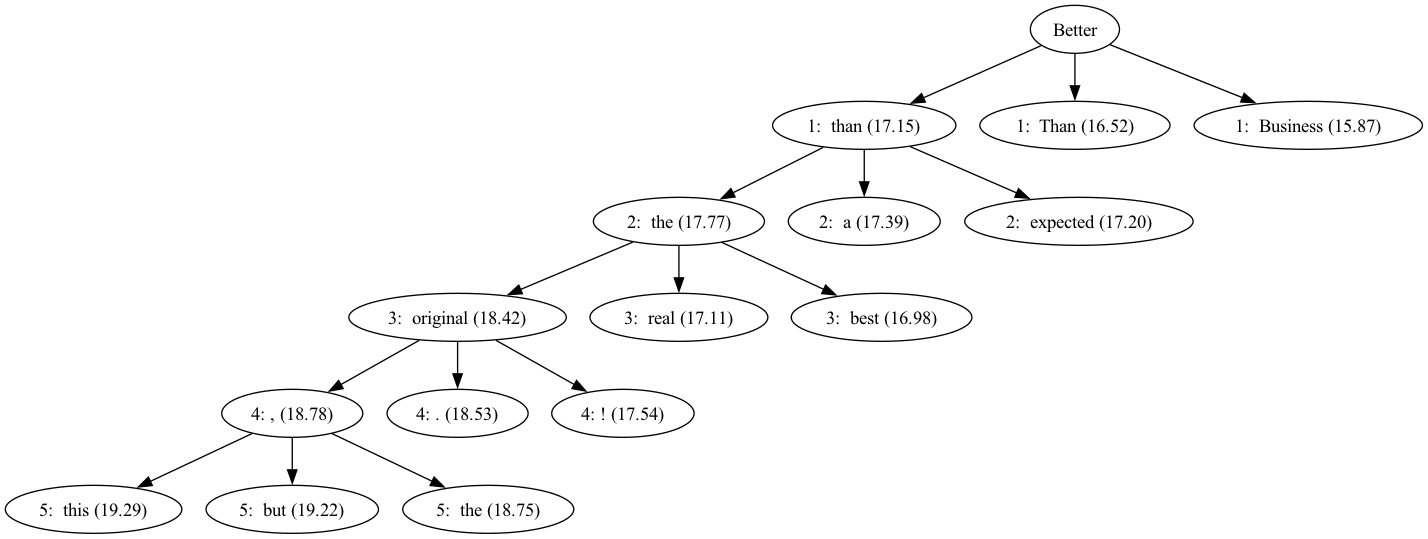

In [ ]:
def greedy_decode_one_sentence_with_visualization(prompt, max_length=10, export_figure_filename="decode_tree_greedy.png"):
    pass  # TODO

greedy_decode_one_sentence_with_visualization("Better")
display(Image(filename="decode_tree_greedy.png"))

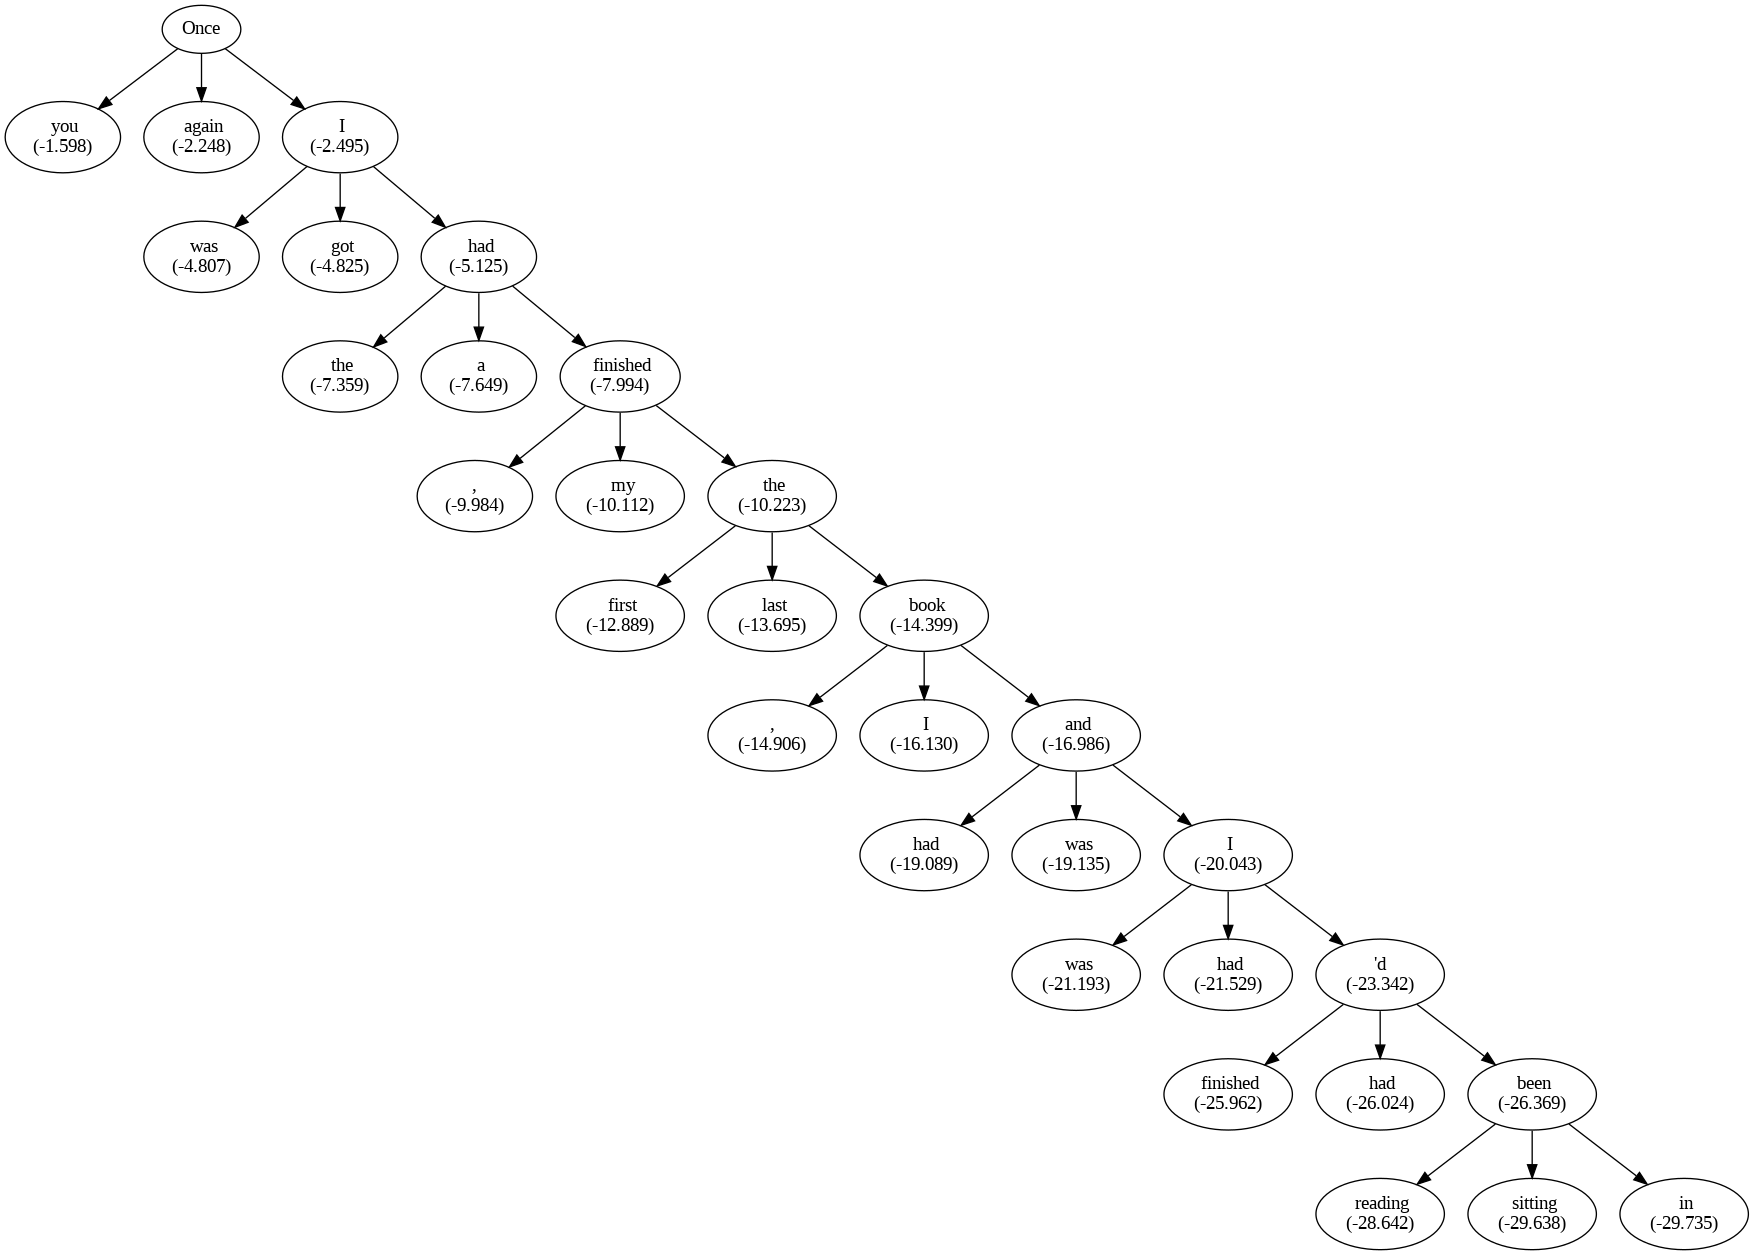

In [51]:
def beam_decode_one_sentence_with_visualization(prompt, max_length=10, k=3, export_figure_filename="decode_tree_beam.png"):
    # TODO
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    root = Node(prompt)
    nodes_by_beam = {0: root}
    beams = {0: (input_ids, 0.0)}

    for step in range(max_length):
        new_beams = {}
        all_candidates = []

        for beam_idx, (beam_ids, beam_prob) in beams.items():
            with torch.no_grad():
                outputs = model(beam_ids)

            next_token_logits = outputs.logits[0, -1, :]
            log_probs = torch.log_softmax(next_token_logits, dim=-1)
            top_k_log_probs, top_k_ids = torch.topk(log_probs, k)

            for idx in range(k):
                next_id = top_k_ids[idx].item()
                next_log_prob = top_k_log_probs[idx].item()
                total_log_prob = beam_prob + next_log_prob

                word = tokenizer.decode([next_id])
                parent = nodes_by_beam[beam_idx]
                child = Node(f"{word}\n({total_log_prob:.3f})", parent=parent)

                new_ids = torch.cat([beam_ids, torch.tensor([[next_id]], device=device)], dim=1)
                all_candidates.append((new_ids, total_log_prob, len(new_beams), child))

        all_candidates.sort(key=lambda x: x[1], reverse=True)
        nodes_by_beam = {}
        for new_ids, total_prob, new_idx, node in all_candidates[:k]:
            new_beams[new_idx] = (new_ids, total_prob)
            nodes_by_beam[new_idx] = node

        beams = new_beams

    DotExporter(root).to_picture(export_figure_filename)
    return root

beam_decode_one_sentence_with_visualization("Once")
display(Image(filename="decode_tree_beam.png"))

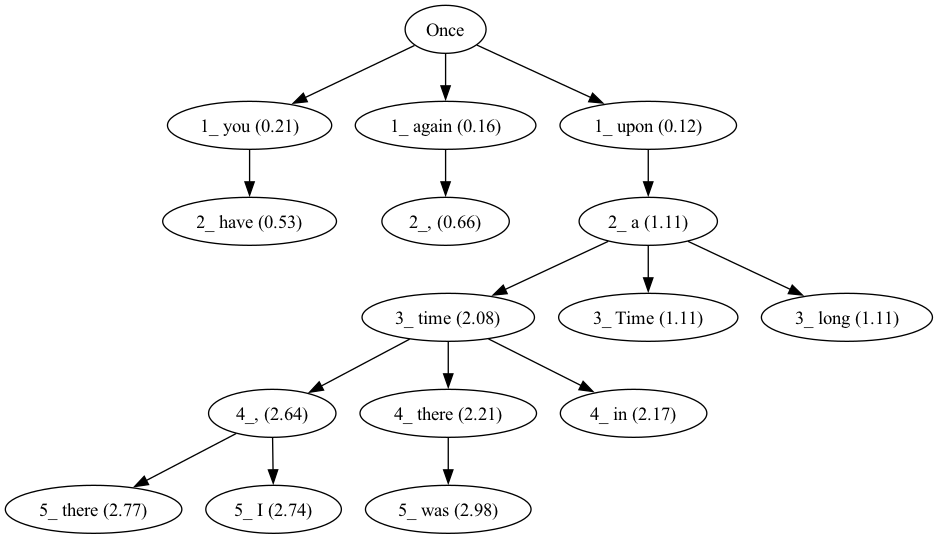

In [ ]:
def beam_decode_one_sentence_with_visualization(prompt, max_length=10, k=3, export_figure_filename="decode_tree_beam.png"):
    pass  # TODO

beam_decode_one_sentence_with_visualization("Once")
display(Image(filename="decode_tree_beam.png"))

### 5. Generation and hyperparameters (10')
1. Use the huggingface's built-in `generate` method. Starting from an initial word of the sentence, e.g., "A", "The" or "Once", generate up to 10 new tokens, using nucleus sampling. Start with the following hyperparameter configuration for nucleus sampling is: `do_sample=True, top_p=0.8`  
[The official doc](https://huggingface.co/docs/transformers/en/generation_strategies#customize-text-generation) briefly describes the generation modes, and [the GenerationConfig doc](https://huggingface.co/docs/transformers/main/en/main_classes/text_generation#transformers.GenerationConfig) explains in details the generation parameters.  
How long does it take to generate a sequence? What is the generation quality?  

1. Change the `temperature` and `top_p` generation hyperparameters. Comment on the results.  

In [53]:
# TODO: Nucleus sampling
import time

print("Nucleus Sampling (top_p=0.8, do_sample=True)")
start = time.time()
input_ids = tokenizer.encode("A", return_tensors="pt").to(device)
outputs = model.generate(input_ids, max_new_tokens=10, do_sample=True, top_p=0.8, temperature=1.0)
generation_time = time.time() - start
print(f"Generated: {tokenizer.decode(outputs[0])}")
print(f"Generation time: {generation_time:.4f}s\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Nucleus Sampling (top_p=0.8, do_sample=True)
Generated: A. The number of patients with type 2 diabetes in
Generation time: 0.3072s



In [54]:
# TODO: Nucleus sampling with different temperature
temperatures = [0.5, 1.0, 1.5]
for temp in temperatures:
    print(f"Temperature: {temp}, top_p=0.8")
    input_ids = tokenizer.encode("The", return_tensors="pt").to(device)
    outputs = model.generate(input_ids, max_new_tokens=10, do_sample=True, top_p=0.8, temperature=temp)
    print(f"Generated: {tokenizer.decode(outputs[0])}\n")

# Different top_p values
top_p_values = [0.5, 0.8, 0.95]
for top_p in top_p_values:
    print(f"top_p: {top_p}, temperature=1.0")
    input_ids = tokenizer.encode("Once", return_tensors="pt").to(device)
    outputs = model.generate(input_ids, max_new_tokens=10, do_sample=True, top_p=top_p, temperature=1.0)
    print(f"Generated: {tokenizer.decode(outputs[0])}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Temperature: 0.5, top_p=0.8
Generated: The first thing I did was to go to the doctor

Temperature: 1.0, top_p=0.8
Generated: The same problem occurs when you run a database as a

Temperature: 1.5, top_p=0.8


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generated: The American Journal of Clinical Nutrition, published by the Department

top_p: 0.5, temperature=1.0
Generated: Once again, the US government has been caught out in

top_p: 0.8, temperature=1.0
Generated: Once I get to the point where I need to make

top_p: 0.95, temperature=1.0
Generated: Once you get a few points, try not to make

